2025-02-13 10:37:32,959 - INFO - Loading spectral data...
2025-02-13 10:37:32,960 - INFO - Processing XYZ data...
2025-02-13 10:37:32,961 - INFO - Normalizing data...
2025-02-13 10:37:32,962 - INFO - Augmenting training data...
2025-02-13 10:37:32,963 - INFO - Training the model...
2025-02-13 10:37:32,971 - INFO - Epoch 1/10000 - MSE Loss: 0.05323709174990654
2025-02-13 10:37:32,977 - INFO - Epoch 2/10000 - MSE Loss: 0.06268715113401413
2025-02-13 10:37:32,984 - INFO - Epoch 3/10000 - MSE Loss: 0.026445297524333
2025-02-13 10:37:32,989 - INFO - Epoch 4/10000 - MSE Loss: 0.04786626622080803
2025-02-13 10:37:32,994 - INFO - Epoch 5/10000 - MSE Loss: 0.04986109212040901
2025-02-13 10:37:33,000 - INFO - Epoch 6/10000 - MSE Loss: 0.02936231531202793
2025-02-13 10:37:33,006 - INFO - Epoch 7/10000 - MSE Loss: 0.028506586328148842
2025-02-13 10:37:33,011 - INFO - Epoch 8/10000 - MSE Loss: 0.04381059482693672
2025-02-13 10:37:33,017 - INFO - Epoch 9/10000 - MSE Loss: 0.04770582541823387
2025-02

Mean ΔE2000 Error: 9.323612075896559
Max ΔE2000 Error: 47.707899579919236


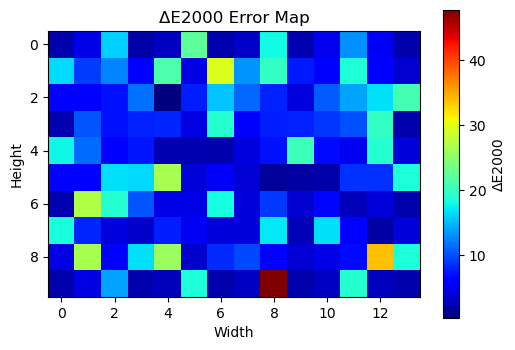

In [4]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import logging
from sklearn.preprocessing import MinMaxScaler
import spectral
import random
from skimage import color
import matplotlib.pyplot as plt

# Set up logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

# Set a fixed seed for reproducibility
seed = 10
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)  # If using GPU

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

###########################################
# Helper functions
###########################################
def process_xyz(cube, bands, ill, CMFs):
    """
    Converts hyperspectral cube data to XYZ.
    """
    ill_interp = np.interp(bands, ill[:, 0], ill[:, 1])
    CMFs_interp = np.column_stack([
        np.interp(bands, CMFs[:, 0], CMFs[:, 1]),
        np.interp(bands, CMFs[:, 0], CMFs[:, 2]),
        np.interp(bands, CMFs[:, 0], CMFs[:, 3])
    ])
    sp_tristREF = CMFs_interp * ill_interp[:, None]
    xyz = np.dot(cube, sp_tristREF) / np.sum(sp_tristREF[:, 1], axis=0)

    # Fix potential NaNs
    xyz = np.nan_to_num(xyz)

    return xyz

def augment_exposure(data, exposure_factors):
    """
    Augments data by scaling pixel values to simulate different exposure levels.
    """
    augmented_data = []
    for factor in exposure_factors:
        augmented = data * factor
        augmented = np.clip(augmented, 0, 1)  # Keep valid range
        augmented_data.append(augmented)
    return np.vstack(augmented_data)

###########################################
# Load spectral data
###########################################
logging.info('Loading spectral data...')
ill = np.loadtxt('../../data/CIE_D65.txt')          
CMFs = np.loadtxt('../../data/CIE2degCMFs_1931.txt')

cube = spectral.open_image('../../data/colorChecker_SG/cubes/cubeCC_120f-ekta100-f14.hdr')
cube_ref = spectral.open_image('../../data/colorChecker_SG/cubeCC_DigitalSG_REF.hdr')

cube_data = cube.load()
cube_ref_data = cube_ref.load()

wl_input = np.array(cube.metadata['wavelength'], dtype=float)
wl_ref   = np.array(cube_ref.metadata['wavelength'], dtype=float)

###########################################
# Process XYZ data
###########################################
logging.info('Processing XYZ data...')
xyz_input = process_xyz(cube_data, wl_input, ill, CMFs)   
xyz_ref   = process_xyz(cube_ref_data, wl_ref, ill, CMFs)   

###########################################
# Normalize data
###########################################
logging.info('Normalizing data...')
xyz_input_2d = xyz_input.reshape(-1, xyz_input.shape[-1])
xyz_ref_2d   = xyz_ref.reshape(-1, xyz_ref.shape[-1])

scaler_input = MinMaxScaler()
scaler_ref = MinMaxScaler()

X_norm = scaler_input.fit_transform(xyz_input_2d)
Y_norm = scaler_ref.fit_transform(xyz_ref_2d)

X_full = X_norm.reshape(xyz_input.shape)
Y_full = Y_norm.reshape(xyz_ref.shape)

###########################################
# Prepare training data
###########################################
logging.info('Augmenting training data...')
exposure_factors = [0.5, 1.0, 1.5]
X_augmented = augment_exposure(X_full, exposure_factors)
Y_augmented = np.tile(Y_full, (len(exposure_factors), 1, 1, 1))

X_flat = X_augmented.reshape(-1, 3)
Y_flat = Y_augmented.reshape(-1, 3)

# Fix NaNs
X_flat = np.nan_to_num(X_flat)
Y_flat = np.nan_to_num(Y_flat)

n_pixels = X_flat.shape[0]
train_size = int(0.8 * n_pixels)
train_indices = np.random.choice(n_pixels, train_size, replace=False)
test_indices = np.setdiff1d(np.arange(n_pixels), train_indices)

X_train_split = X_flat[train_indices]
X_test_split  = X_flat[test_indices]
Y_train_split = Y_flat[train_indices]
Y_test_split  = Y_flat[test_indices]

X_train_torch = torch.tensor(X_train_split, dtype=torch.float32)
Y_train_torch = torch.tensor(Y_train_split, dtype=torch.float32)
X_test_torch  = torch.tensor(X_test_split, dtype=torch.float32)
Y_test_torch  = torch.tensor(Y_test_split, dtype=torch.float32)

###########################################
# Define Neural Network
###########################################
class ExposureInvariantNN(nn.Module):
    def __init__(self):
        super(ExposureInvariantNN, self).__init__()
        self.fc1 = nn.Linear(2, 79)
        self.elu = nn.ELU()
        self.fc2 = nn.Linear(79, 36)
        self.elu2 = nn.ELU()
        self.fc3 = nn.Linear(36, 3)
        self.luminance_fc = nn.Linear(1, 1)

    def forward(self, x):
        sum_rgb = torch.sum(x, dim=1, keepdim=True) + 1e-6  # Fix division by zero
        chromaticity = x[:, :2] / sum_rgb

        chroma = self.elu(self.fc1(chromaticity))
        chroma = self.elu2(self.fc2(chroma))
        chroma = self.fc3(chroma)

        luminance = self.luminance_fc(sum_rgb)
        output = chroma * luminance
        return output

model = ExposureInvariantNN()
optimizer = optim.Adam(model.parameters(), lr=0.001)
loss_function = nn.MSELoss()

###########################################
# Training
###########################################
logging.info('Training the model...')
epochs = 10000
batch_size = 32

for epoch in range(epochs):
    model.train()
    perm = torch.randperm(X_train_torch.size(0))
    X_train_shuffled = X_train_torch[perm]
    Y_train_shuffled = Y_train_torch[perm]

    for i in range(0, X_train_shuffled.size(0), batch_size):
        X_batch = X_train_shuffled[i:i+batch_size]
        Y_batch = Y_train_shuffled[i:i+batch_size]

        optimizer.zero_grad()
        Y_pred = model(X_batch)
        loss = loss_function(Y_pred, Y_batch)
        loss.backward()
        optimizer.step()

    logging.info(f'Epoch {epoch+1}/{epochs} - MSE Loss: {loss.item()}')

###########################################
# Apply Correction
###########################################
X_full_flat = np.nan_to_num(X_full.reshape(-1, 3))
corrected_flat = model(torch.tensor(X_full_flat, dtype=torch.float32)).detach().numpy()
corrected_flat = np.clip(corrected_flat, 0, 1)  # Prevent NaNs
corrected_xyz = scaler_ref.inverse_transform(corrected_flat)
corrected_xyz_image = corrected_xyz.reshape(xyz_ref.shape)

lab_ref = color.xyz2lab(xyz_ref)
lab_corrected = color.xyz2lab(corrected_xyz_image)

# Compute ΔE2000 error map
error_map = color.deltaE_ciede2000(lab_ref, lab_corrected)

# Compute mean ΔE2000 error
mean_error = np.mean(error_map)
max_error = np.max(error_map)
logging.info(f"Mean ΔE2000 Error on test set: {mean_error}")
print("Mean ΔE2000 Error:", mean_error)
print("Max ΔE2000 Error:", max_error)

# Plot the ΔE2000 error map
plt.figure(figsize=(6, 4))
plt.imshow(error_map, cmap='jet')
plt.colorbar(label='ΔE2000')
plt.title('ΔE2000 Error Map')
plt.xlabel('Width')
plt.ylabel('Height')
plt.show()

